In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import pop_tools
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
# Here we point to the archive directory from a longer B1850 simulation
monthly_output_path = "/glade/campaign/cesm/tutorial/diagnostics_tutorial_archive/b1850.run_length/ice/hist"

# Name of CESM run
run_name = "b1850.run_length"

# Create path to all files, including unix wild card for all dates
files = os.path.join(monthly_output_path, run_name + ".cice.h.*")

# read in files as an xarray dataset:
ds = xr.open_mfdataset(files)

# For this analysis, choose which variable to keep. Start with `aice` and then later try `hi`
# var_in = 'aice'    # sea ice concentration
var_in = 'hi'      # sea ice thickness

var_to_keep = ds[var_in]

var_to_keep

/glade/derecho/scratch/skygale/tmp/ipykernel_102664/3648809336.py:11: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files)


<xarray.DataArray 'hi' (time: 40, nj: 384, ni: 320)> Size: 20MB
dask.array<concatenate, shape=(40, 384, 320), dtype=float32, chunksize=(1, 384, 320), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 320B 0001-02-01 00:00:00 ... 0004-05-01 00:00:00
    TLON     (nj, ni) float32 492kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nj, ni) float32 492kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULON     (nj, ni) float32 492kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nj, ni) float32 492kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nj, ni
Attributes:
    units:          m
    long_name:      grid cell mean ice thickness
    cell_measures:  area: tarea
    cell_methods:   time: mean
    time_rep:       averaged

In [3]:
# get pop grid grid cell areas
grid = pop_tools.get_grid('POP_gx1v7')

# convert tarea to m^2
with xr.set_options(keep_attrs=True):
    grid['TAREA'] = grid['TAREA']/(1e4)
grid['TAREA'].attrs['units'] = 'm^2'

grid

grid['TLONG']

<xarray.DataArray 'TLONG' (nlat: 384, nlon: 320)> Size: 983kB
array([[320.56250892, 321.68750895, 322.81250898, ..., 317.18750883,
        318.31250886, 319.43750889],
       [320.56250892, 321.68750895, 322.81250898, ..., 317.18750883,
        318.31250886, 319.43750889],
       [320.56250892, 321.68750895, 322.81250898, ..., 317.18750883,
        318.31250886, 319.43750889],
       ...,
       [320.25133086, 320.75380113, 321.25577325, ..., 318.74424456,
        319.24621668, 319.74869143],
       [320.23459477, 320.70358949, 321.17207442, ..., 318.82794339,
        319.29642832, 319.76542721],
       [320.21650899, 320.6493303 , 321.08163473, ..., 318.91838308,
        319.3506875 , 319.78351267]], shape=(384, 320))
Dimensions without coordinates: nlat, nlon
Attributes:
    units:      degrees_east
    long_name:  T-grid longitude

In [9]:
ds = xr.merge([var_to_keep.drop(['TLAT', 'TLON', 'ULAT', 'ULON']),
               grid[['TLAT', 'TLONG', 'TAREA']].rename_dims({'nlat':'nj','nlon':'ni'})],
              compat='identical', combine_attrs='no_conflicts')
grid['TLAT']

/glade/derecho/scratch/skygale/tmp/ipykernel_20805/1428857956.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds = xr.merge([var_to_keep.drop(['TLAT', 'TLON', 'ULAT', 'ULON']),


<xarray.DataArray 'TLAT' (nlat: 384, nlon: 320)> Size: 983kB
array([[-79.22052261, -79.22052261, -79.22052261, ..., -79.22052261,
        -79.22052261, -79.22052261],
       [-78.68630626, -78.68630626, -78.68630626, ..., -78.68630626,
        -78.68630626, -78.68630626],
       [-78.15208992, -78.15208992, -78.15208992, ..., -78.15208992,
        -78.15208992, -78.15208992],
       ...,
       [ 71.29031715,  71.29408252,  71.30160692, ...,  71.30160692,
         71.29408252,  71.29031716],
       [ 71.73524335,  71.73881845,  71.74596231, ...,  71.74596231,
         71.73881845,  71.73524335],
       [ 72.18597561,  72.18933231,  72.19603941, ...,  72.19603941,
         72.18933231,  72.18597562]], shape=(384, 320))
Dimensions without coordinates: nlat, nlon
Attributes:
    units:      degrees_north
    long_name:  T-grid latitude

/glade/derecho/scratch/skygale/tmp/ipykernel_20805/3614413937.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues')


Text(0.5, 1.0, 'Sea Ice Thickness')

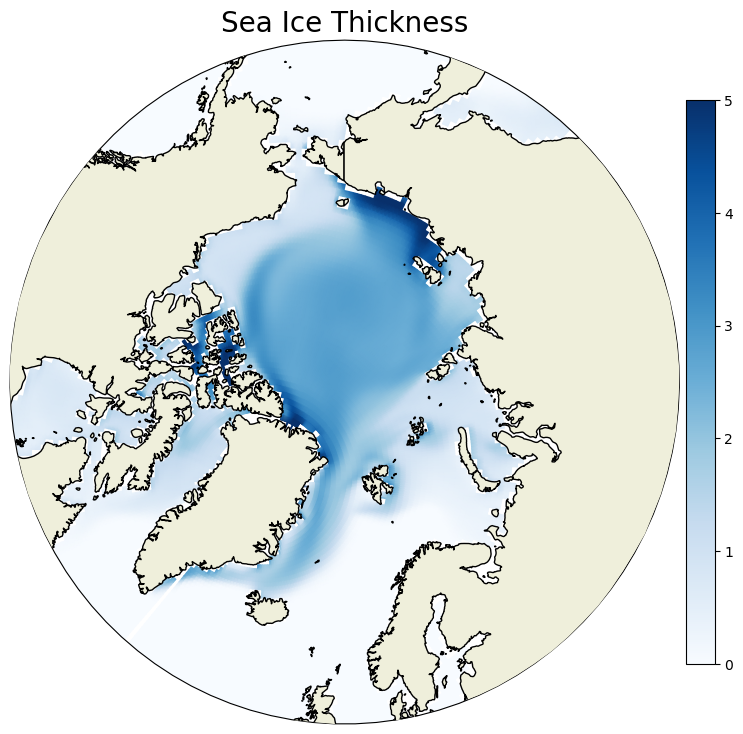

In [12]:
# make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# define the colormap
cmap = plt.cm.get_cmap('Blues')

# set up the figure with a North Polar Stereographic projection
fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(1,2,1, projection=ccrs.NorthPolarStereo())
ax.set_boundary(circle, transform=ax.transAxes)
ax.add_feature(cfeature.LAND,zorder=100,edgecolor='k')

# sets the latitude / longitude boundaries of the plot
ax.set_extent([0.005, 360, 90, 55], crs=ccrs.PlateCarree())

#Plot the first timeslice of aice
this=ax.pcolormesh(ds['TLONG'],
                   ds['TLAT'],
                   ds[var_in].isel(time=0).squeeze(),
                   cmap=cmap,vmax=5,vmin=0,
                   shading='gouraud',
                   transform=ccrs.PlateCarree())
plt.colorbar(this,orientation='vertical',fraction=0.04,pad=0.01)
plt.title('Sea Ice Thickness',fontsize=20)